In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
HORIZON = 336

LAGS=[
    336,
    672,   # Jour 14
    1344,  # Jour 28
]

TARGETS = [
    'consommation_telerelevee_hta',
    'consommation_telerelevee_btsup',
    'consommation_telerelevee_professionnelle',
    'consommation_telerelevee_residentielle'
]


In [35]:
df=pd.read_csv("C:/Users/T14s/Desktop/ml-project/data/features.csv", parse_dates=['datetime'])

In [36]:
df=df.sort_values('datetime').reset_index(drop=True)
df=df.set_index('datetime')
df=df.drop(columns=['timestamp'])

In [37]:
df.dtypes

year_utc                                      int64
month_utc                                     int64
day                                           int64
day_of_week                                   int64
est_weekend                                   int64
est_ferie                                     int64
hour_utc                                      int64
minute_utc                                    int64
temperature_reelle_lissee                   float64
temperature_normale_lissee                  float64
ecart_temperature                           float64
temp_x_weekend                              float64
temp_x_ferier                               float64
degre_jour_chauffage                        float64
degre_jour_clim                             float64
pseudo_rayonnement                            int64
consommation_telerelevee_hta                  int64
consommation_telerelevee_btsup                int64
consommation_telerelevee_professionnelle      int64
consommation

In [38]:
df

,year_utc,month_utc,day,day_of_week,est_weekend,est_ferie,hour_utc,minute_utc,temperature_reelle_lissee,temperature_normale_lissee,ecart_temperature,temp_x_weekend,temp_x_ferier,degre_jour_chauffage,degre_jour_clim,pseudo_rayonnement,consommation_telerelevee_hta,consommation_telerelevee_btsup,consommation_telerelevee_professionnelle,consommation_telerelevee_residentielle
datetime,,,,,,,,,,,,,,,,,,,,
2021-01-17 00:00:00,2021,1,17,6,1,0,23,0,3.6,4.8,-1.2,3.6,0.0,14.4,0.0,44,9430212494,2294649278,856481,131229178
2021-01-17 00:30:00,2021,1,17,6,1,0,23,30,3.6,4.8,-1.2,3.6,0.0,14.4,0.0,48,9390564641,2267123866,859306,127459026
2021-01-17 01:00:00,2021,1,17,6,1,0,0,0,3.7,4.8,-1.1,3.7,0.0,14.3,0.0,52,9345144665,2264800449,843820,132283952
2021-01-17 01:30:00,2021,1,17,6,1,0,0,30,3.7,4.8,-1.1,3.7,0.0,14.3,0.0,51,9302935353,2246466416,825465,135308004
2021-01-17 02:00:00,2021,1,17,6,1,0,1,0,3.7,4.8,-1.1,3.7,0.0,14.3,0.0,49,9275972138,2252622971,827802,178543670
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 22:30:00,2025,12,31,2,0,0,21,30,1.1,4.6,-3.5,0.0,0.0,16.9,0.0,86,9080170739,5523822369,25743723,630493094
2025-12-31 23:00:00,2025,12,31,2,0,0,22,0,1.1,4.6,-3.5,0.0,0.0,16.9,0.0,84,9069136925,5542965259,26812391,630210095
2025-12-31 23:30:00,2025,12,31,2,0,0,22,30,1.1,4.6,-3.5,0.0,0.0,16.9,0.0,83,8986842522,5462433633,26538657,637219083


In [39]:

time_diffs=df.index.to_series().diff()
expected_step=pd.Timedelta('30min')
gaps=time_diffs[time_diffs > expected_step]

print(gaps)

datetime
2021-03-28 03:00:00   0 days 01:30:00
2022-03-27 03:00:00   0 days 01:30:00
2023-03-26 03:00:00   0 days 01:30:00
2024-03-31 03:00:00   0 days 01:30:00
2025-03-30 03:00:00   0 days 01:30:00
Name: datetime, dtype: timedelta64[ns]


In [40]:
df[TARGETS].describe().T

,count,mean,std,min,25%,50%,75%,max
consommation_telerelevee_hta,86882.0,1.171623e+10,2.486988e+09,6.999606e+09,9.538830e+09,1.128747e+10,1.396687e+10,1.775633e+10
consommation_telerelevee_btsup,86882.0,3.743274e+09,1.720369e+09,1.139662e+09,2.301729e+09,3.475179e+09,4.892146e+09,1.003807e+10
consommation_telerelevee_professionnelle,86882.0,5.714332e+06,5.050324e+06,4.177110e+05,2.083942e+06,3.637241e+06,8.681579e+06,3.023862e+07
consommation_telerelevee_residentielle,86882.0,2.134210e+08,1.213608e+08,3.699746e+07,1.220798e+08,1.848764e+08,2.729395e+08,6.990839e+08


In [41]:
df['halfhour_of_day'] = df['hour_utc'] * 2 + (df['minute_utc'] // 30)

df['jour_fetes'] = df.apply(
    lambda r: r['day'] - 24 
    if r['month_utc'] == 12 and r['day'] >= 24 
    else (r['day'] + 7 
    if r['month_utc'] == 1 and r['day'] == 1 
    else 0), axis=1
)

for target in TARGETS:
    for lag in LAGS:
        col_name = f'{target}_lag_{lag}'
        df[col_name] = df[target].shift(lag)

In [ ]:
df['week_index'] = (
    (df.index - df.index.min()).days // 7
).astype(int)

df['activite_pro'] = 1
df.loc[df['est_ferie'] == 1, 'activite_pro'] = 0
df.loc[df['day_of_week'] >= 5, 'activite_pro'] = 0
df.loc[
    (df['month_utc'] == 12) & (df['day'] >= 25),
    'activite_pro'
] = 0

In [50]:
df['activite_commerciale'] = 2
df.loc[df['day_of_week'] == 6, 'activite_commerciale'] = 1

df.loc[df['est_ferie'] == 1, 'activite_commerciale'] = 0

df.loc[
    (df['month_utc'] == 12) & (df['day'].isin([25, 26])),
    'activite_commerciale'
] = 0
df.loc[
    (df['month_utc'] == 1) & (df['day'] == 1),
    'activite_commerciale'
] = 0

In [43]:
rolling_windows = {
    336 : 'mean',
    336 : 'std',
}

for target in TARGETS:
    shifted = df[target].shift(HORIZON)
    df[f'{target}_rolling_mean_336'] = shifted.rolling(window=336, min_periods=168).mean()
    df[f'{target}_rolling_std_336']  = shifted.rolling(window=336, min_periods=168).std()


In [44]:
n_avant= len(df)
df= df.dropna()
n_apres= len(df)

print(f'Lignes avant dropna: {n_avant}')
print(f'Lignes après dropna: {n_apres}')

Lignes avant dropna: 86882
Lignes après dropna: 85538


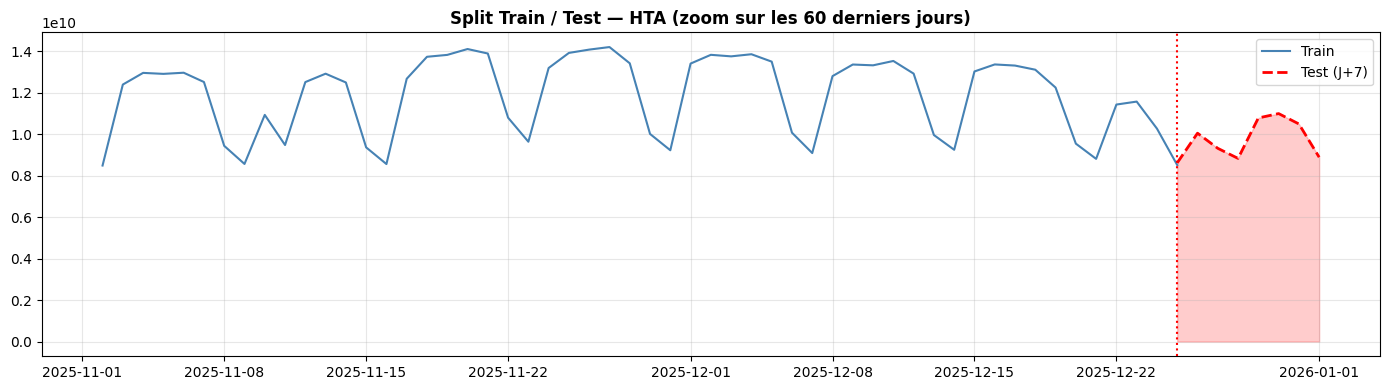

In [45]:
TEST_STEPS= HORIZON
train_df= df.iloc[:-TEST_STEPS]
test_df= df.iloc[-TEST_STEPS:]
fig, ax= plt.subplots(figsize=(14, 4))

zoom=df.iloc[-(60*48):]
train_zoom=zoom.iloc[:-TEST_STEPS]['consommation_telerelevee_hta'].resample('D').mean()
test_zoom=zoom.iloc[-TEST_STEPS:]['consommation_telerelevee_hta'].resample('D').mean()

ax.plot(train_zoom.index, train_zoom.values, color='steelblue', label='Train', linewidth=1.5)
ax.plot(test_zoom.index, test_zoom.values, color='red', label='Test (J+7)', 
        linewidth=2, linestyle='--')
ax.fill_between(test_zoom.index, test_zoom.values, alpha=0.2, color='red')
ax.axvline(x=test_zoom.index[0], color='red', linestyle=':', linewidth=1.5)
ax.set_title('Split Train / Test — HTA (zoom sur les 60 derniers jours)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
df_out = df.reset_index()
print(df_out.isnull().sum().sum())

df_out.to_csv("C:/Users/T14s/Desktop/ml-project/data/features_with_lags.csv", index=False)

0


In [52]:
df_out.columns

Index(['datetime', 'year_utc', 'month_utc', 'day', 'day_of_week',
       'est_weekend', 'est_ferie', 'hour_utc', 'minute_utc',
       'temperature_reelle_lissee', 'temperature_normale_lissee',
       'ecart_temperature', 'temp_x_weekend', 'temp_x_ferier',
       'degre_jour_chauffage', 'degre_jour_clim', 'pseudo_rayonnement',
       'consommation_telerelevee_hta', 'consommation_telerelevee_btsup',
       'consommation_telerelevee_professionnelle',
       'consommation_telerelevee_residentielle', 'halfhour_of_day',
       'jour_fetes', 'consommation_telerelevee_hta_lag_336',
       'consommation_telerelevee_hta_lag_672',
       'consommation_telerelevee_hta_lag_1344',
       'consommation_telerelevee_btsup_lag_336',
       'consommation_telerelevee_btsup_lag_672',
       'consommation_telerelevee_btsup_lag_1344',
       'consommation_telerelevee_professionnelle_lag_336',
       'consommation_telerelevee_professionnelle_lag_672',
       'consommation_telerelevee_professionnelle_lag_1344'